In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor
import shap
from scipy.stats import zscore
from scipy.spatial import cKDTree
import os
import random
import fiona
from geopy.distance import geodesic
from shapely.geometry import LineString

In [2]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
caserne = gpd.read_file("../data/caserne/2024_06_21_CIS.shp")
compagnies = gpd.read_file("../data/caserne/2024_06_21_Compagnies.shp")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_doubs = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")

In [3]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def encode_cyclic_feature(df, col, max_val):
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / max_val)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / max_val)
    return df

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

def remove_highly_correlated_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    print(f"🛑 Suppression de {len(to_drop)} features corrélées: {to_drop}")

    return X.drop(columns=to_drop)


doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [4]:
doubs_data = doubs_data.merge(firepoint_doubs, on='hex_id', how='left')

threshold = 0.7 * len(doubs_data)
doubs_data.dropna(axis=1, thresh=threshold, inplace=True)

doubs_data.dropna(inplace=True)

threshold = 0.7 * len(firepoint_doubs)
firepoint_doubs.dropna(axis=1, thresh=threshold, inplace=True)

firepoint_doubs.dropna(inplace=True)

In [5]:
doubs_data.head()

,hex_id,raison_sortie,date_debut,date_fin,label,year,date,departement,duree_minutes,geometry_x,...,tree,grass,crops,shrub,flooded,built,bare,snow,sinister,geometry_y
0,871f820aaffffff,NATURELS,2014-10-02 14:08:53,2014-10-02 19:54:25,1.0,2014.0,2014-10-02,departement-25-doubs,345.533333,"POLYGON ((6.21735 46.89696, 6.21925 46.88490, ...",...,0.062996,27.063122,0.478770,1.713494,0.062996,3.112007,0.604763,0.0,1.0,"POLYGON ((6.21735 46.89696, 6.21925 46.88490, ..."
1,871f82d61ffffff,NATURELS,2014-10-03 19:33:59,2014-10-03 19:55:31,1.0,2014.0,2014-10-03,departement-25-doubs,21.533333,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",...,20.035394,7.976236,1.453672,17.671597,0.037922,6.345595,0.000000,0.0,2.0,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ..."
2,871f82d61ffffff,NATURELS,2014-10-04 19:24:49,2014-10-04 19:59:02,1.0,2014.0,2014-10-04,departement-25-doubs,34.216667,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",...,20.035394,7.976236,1.453672,17.671597,0.037922,6.345595,0.000000,0.0,2.0,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ..."
3,871f82d4dffffff,NATURELS,2014-10-04 20:10:43,2014-10-04 20:42:34,1.0,2014.0,2014-10-04,departement-25-doubs,31.850000,"POLYGON ((5.87805 47.22180, 5.88000 47.20981, ...",...,72.897196,0.252589,0.063147,1.780753,0.025259,10.204597,0.000000,0.0,6.0,"POLYGON ((5.87805 47.22180, 5.88000 47.20981, ..."
4,871f82700ffffff,NATURELS,2014-10-05 12:57:52,2014-10-05 13:24:24,1.0,2014.0,2014-10-05,departement-25-doubs,26.533333,"POLYGON ((6.30249 46.75999, 6.30437 46.74791, ...",...,22.315922,13.442417,0.478288,0.138452,0.088106,11.164254,0.000000,0.0,2.0,"POLYGON ((6.30249 46.75999, 6.30437 46.74791, ..."


In [6]:
cols_to_drop = [
    'geometry_y'
]

doubs_data = doubs_data.drop(columns=cols_to_drop).rename(columns={'geometry_x': 'geometry'})

print(doubs_data.head())

            hex_id raison_sortie          date_debut            date_fin  \
0  871f820aaffffff      NATURELS 2014-10-02 14:08:53 2014-10-02 19:54:25   
1  871f82d61ffffff      NATURELS 2014-10-03 19:33:59 2014-10-03 19:55:31   
2  871f82d61ffffff      NATURELS 2014-10-04 19:24:49 2014-10-04 19:59:02   
3  871f82d4dffffff      NATURELS 2014-10-04 20:10:43 2014-10-04 20:42:34   
4  871f82700ffffff      NATURELS 2014-10-05 12:57:52 2014-10-05 13:24:24   

   label    year       date           departement  duree_minutes  \
0    1.0  2014.0 2014-10-02  departement-25-doubs     345.533333   
1    1.0  2014.0 2014-10-03  departement-25-doubs      21.533333   
2    1.0  2014.0 2014-10-04  departement-25-doubs      34.216667   
3    1.0  2014.0 2014-10-04  departement-25-doubs      31.850000   
4    1.0  2014.0 2014-10-05  departement-25-doubs      26.533333   

                                            geometry  ... water       tree  \
0  POLYGON ((6.21735 46.89696, 6.21925 46.88490, ...  ..

In [7]:
caserne['compagnie'] = caserne['compagnie'].replace('Maîche', 'Maiche')

caserne = caserne.to_crs(epsg=4326)
caserne["lon"] = caserne.geometry.x
caserne["lat"] = caserne.geometry.y
compagnies = compagnies.to_crs(epsg=4326)

caserne = caserne.merge(compagnies[['id', 'nom']], left_on='compagnie', right_on='nom', how='left')

caserne = caserne.rename(columns={'id': 'id_compagnie'})

if 'nom' in caserne.columns:
    caserne = caserne.drop(columns=['nom'])

none_count = caserne['id_compagnie'].isna().sum()
print(f"Nombre de casernes sans id_compagnie : {none_count}")

print(caserne[['compagnie', 'id_compagnie']].head())

if 'nom_y' in caserne.columns:
    caserne = caserne.drop(columns=['nom_y'])

Nombre de casernes sans id_compagnie : 0
         compagnie  id_compagnie
0         Besançon           1.0
1  Baume-les-Dames           2.0
2      Montbéliard           6.0
3       Pontarlier           4.0
4      Montbéliard           6.0


In [8]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
compagnies = gpd.GeoDataFrame(compagnies, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
compagnies = compagnies.to_crs(epsg=4326)

doubs_data['id_compagnie'] = None

for idx, hexagone in doubs_data.iterrows():
    intersecting_companies = compagnies[compagnies.intersects(hexagone['geometry'])]

    if not intersecting_companies.empty:
        doubs_data.at[idx, 'id_compagnie'] = intersecting_companies['id'].tolist()

print(doubs_data[['hex_id', 'id_compagnie']].head())

            hex_id id_compagnie
0  871f820aaffffff        [4.0]
1  871f82d61ffffff       [12.0]
2  871f82d61ffffff       [12.0]
3  871f82d4dffffff  [1.0, 12.0]
4  871f82700ffffff        [5.0]


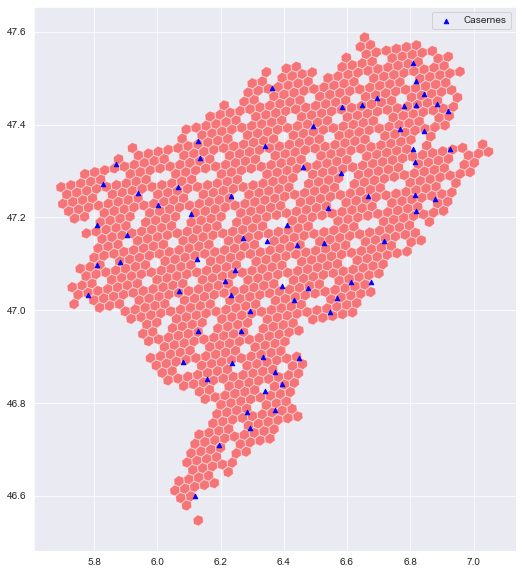

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))

firepoint_doubs.plot(ax=ax, color='red', markersize=5, alpha=0.5, label="Incendies")

caserne.plot(ax=ax, color='blue', markersize=20, marker='^', label="Casernes")

plt.legend()

plt.show()

In [10]:
compagnies.columns

Index(['id', 'nom', 'num', 'geometry'], dtype='object')

In [11]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry').to_crs(epsg=4326)
caserne = gpd.GeoDataFrame(caserne, geometry='geometry').to_crs(epsg=4326)

doubs_data['id_caserne_proche'] = None
doubs_data['distance_caserne_km'] = None
doubs_data['nb_casernes_10km'] = 0

for idx, hexagone in doubs_data.iterrows():
    compagnies_eligibles = hexagone['id_compagnie']

    if not compagnies_eligibles:
        continue

    casernes_eligibles = caserne[caserne['id_compagnie'].isin(compagnies_eligibles)]

    if casernes_eligibles.empty:
        continue

    hex_coords = (hexagone['centroid_lat'], hexagone['centroid_lon'])

    casernes_dans_hexagone = casernes_eligibles[casernes_eligibles.intersects(hexagone['geometry'])]

    if not casernes_dans_hexagone.empty:
        meilleure_caserne = casernes_dans_hexagone.iloc[0]
        doubs_data.at[idx, 'id_caserne_proche'] = meilleure_caserne['id_pg']
        doubs_data.at[idx, 'distance_caserne_km'] = 0
    else:
        min_distance = float('inf')
        meilleure_caserne = None

        for _, cas in casernes_eligibles.iterrows():
            cas_coords = (cas['lat'], cas['lon'])
            distance = geodesic(hex_coords, cas_coords).km

            if distance < min_distance:
                min_distance = distance
                meilleure_caserne = cas

        if meilleure_caserne is not None:
            doubs_data.at[idx, 'id_caserne_proche'] = meilleure_caserne['id_pg']
            doubs_data.at[idx, 'distance_caserne_km'] = round(min_distance, 2)

    doubs_data.at[idx, 'nb_casernes_10km'] = sum(
        geodesic(hex_coords, (cas['lat'], cas['lon'])).km <= 10
        for _, cas in casernes_eligibles.iterrows()
    )

print(doubs_data[['hex_id', 'id_caserne_proche', 'distance_caserne_km', 'nb_casernes_10km']].head())

            hex_id id_caserne_proche distance_caserne_km  nb_casernes_10km
0  871f820aaffffff            840709                   0                 4
1  871f82d61ffffff            840704                 1.9                 2
2  871f82d61ffffff            840704                 1.9                 2
3  871f82d4dffffff            840698                5.15                 5
4  871f82700ffffff            840701                 2.2                 4


In [12]:
firepoint_doubs.columns

Index(['hex_id', 'scale0', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI',
       'PasDeRoute', 'motorway', 'primary', 'secondary', 'tertiary', 'path',
       'population', 'elevation', 'foret_encoder', 'highway_encoder',
       'PasDeforet', 'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas',
       'Feuillus', 'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier',
       'Pin autre', 'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'sinister',
       'geometry'],
      dtype='object')

In [13]:
caserne_proj = caserne.to_crs(epsg=2154)
doubs_data_proj = doubs_data.to_crs(epsg=2154)

caserne_with_hex = gpd.sjoin(caserne_proj, doubs_data_proj[['hex_id', 'geometry']], how="left", predicate="within")

caserne = caserne.merge(caserne_with_hex[['hex_id']], left_index=True, right_index=True, how="left")

print(caserne.head())

    id_pg                    sous_type cs_cod         nom_x compagnie  \
0  840642  Centre de Secours Principal  25155  BESANCON EST  Besançon   
0  840642  Centre de Secours Principal  25155  BESANCON EST  Besançon   
0  840642  Centre de Secours Principal  25155  BESANCON EST  Besançon   
0  840642  Centre de Secours Principal  25155  BESANCON EST  Besançon   
0  840642  Centre de Secours Principal  25155  BESANCON EST  Besançon   

                   geometry       lon        lat  id_compagnie  \
0  POINT (6.06536 47.26571)  6.065359  47.265714           1.0   
0  POINT (6.06536 47.26571)  6.065359  47.265714           1.0   
0  POINT (6.06536 47.26571)  6.065359  47.265714           1.0   
0  POINT (6.06536 47.26571)  6.065359  47.265714           1.0   
0  POINT (6.06536 47.26571)  6.065359  47.265714           1.0   

            hex_id  
0  871f828aaffffff  
0  871f828aaffffff  
0  871f828aaffffff  
0  871f828aaffffff  
0  871f828aaffffff  


Hexagones voisins trouvés :
['871f828b3ffffff' '871f82895ffffff' '871f82880ffffff' '871f82886ffffff'
 '871f82884ffffff' '871f82882ffffff']


Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



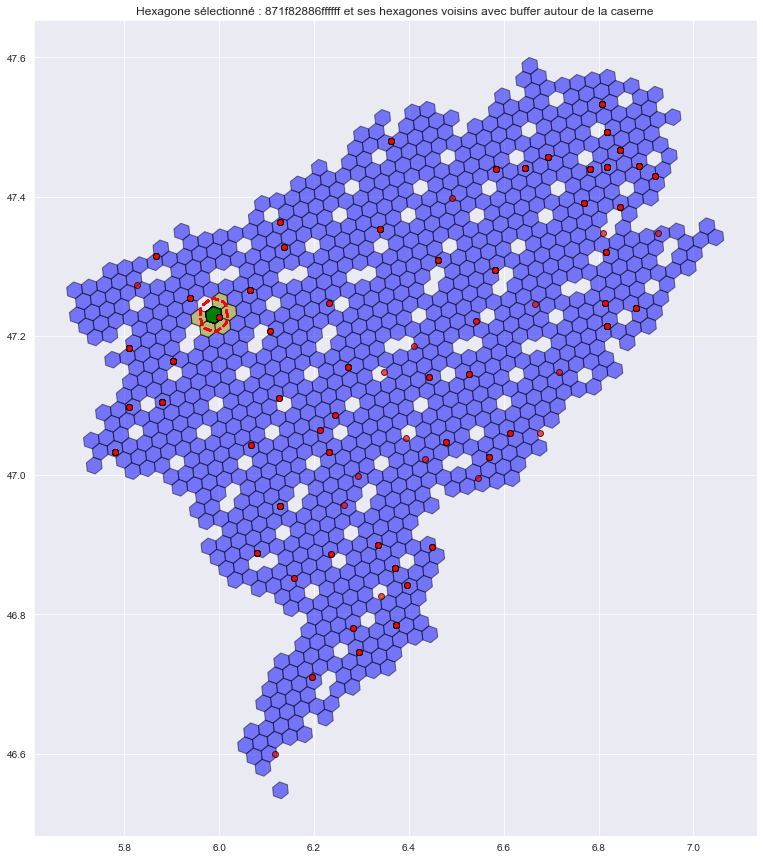

In [14]:
random_idx = random.choice(doubs_data.index)
hex_selection = doubs_data.loc[random_idx]

buffer_hex_selection = hex_selection.geometry.buffer(0.012)

hex_around_selection = firepoint_doubs[firepoint_doubs.geometry.intersects(buffer_hex_selection)]

print("Hexagones voisins trouvés :")
print(hex_around_selection['hex_id'].values)

id_caserne_proche = hex_selection['id_caserne_proche']
caserne_proche = caserne[caserne['id_pg'] == id_caserne_proche]

hex_id_caserne = caserne_proche['hex_id'].values[0]
hex_caserne = doubs_data[doubs_data['hex_id'] == hex_id_caserne]

buffer_hex_caserne = hex_caserne.geometry.buffer(0.012)

fig, ax = plt.subplots(figsize=(15, 15))

firepoint_doubs.plot(ax=ax, color="blue", edgecolor="black", alpha=0.5)

gpd.GeoSeries(buffer_hex_selection).plot(ax=ax, facecolor='none', edgecolor='black', linestyle='--', linewidth=2)

hex_around_selection.plot(ax=ax, color="yellow", edgecolor="black", alpha=0.5)

gpd.GeoSeries(hex_selection.geometry).plot(ax=ax, color="purple", edgecolor="black", alpha=0.7)

gpd.GeoSeries(hex_caserne.geometry).plot(ax=ax, color="green", edgecolor="black", alpha=0.7)

gpd.GeoSeries(buffer_hex_caserne).plot(ax=ax, facecolor='none', edgecolor='red', linestyle='--', linewidth=2)

caserne.plot(ax=ax, color="red", edgecolor="black", alpha=0.7)

plt.title(f"Hexagone sélectionné : {hex_selection['hex_id']} et ses hexagones voisins avec buffer autour de la caserne")

plt.show()

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



Hexagones voisins (buffer autour de l'hexagone sélectionné) :
               hex_id                                           geometry
91    871f82c49ffffff  POLYGON ((6.02655 47.09381, 6.02847 47.08179, ...
239   871f82136ffffff  POLYGON ((6.02077 47.12984, 6.02269 47.11783, ...
264   871f82130ffffff  POLYGON ((6.05208 47.13382, 6.05401 47.12181, ...
770   871f82133ffffff  POLYGON ((6.07063 47.11779, 6.07255 47.10578, ...
845   871f82c4dffffff  POLYGON ((6.00800 47.10983, 6.00993 47.09782, ...
860   871f82114ffffff  POLYGON ((6.05785 47.09778, 6.05977 47.08577, ...
1151  871f82132ffffff  POLYGON ((6.03931 47.11382, 6.04124 47.10180, ...

Hexagones qui croisent la ligne tracée vers la caserne :
               hex_id                                           geometry
49    871f82106ffffff  POLYGON ((6.10196 47.12176, 6.10387 47.10974, ...
770   871f82133ffffff  POLYGON ((6.07063 47.11779, 6.07255 47.10578, ...
1151  871f82132ffffff  POLYGON ((6.03931 47.11382, 6.04124 47.10180, ...


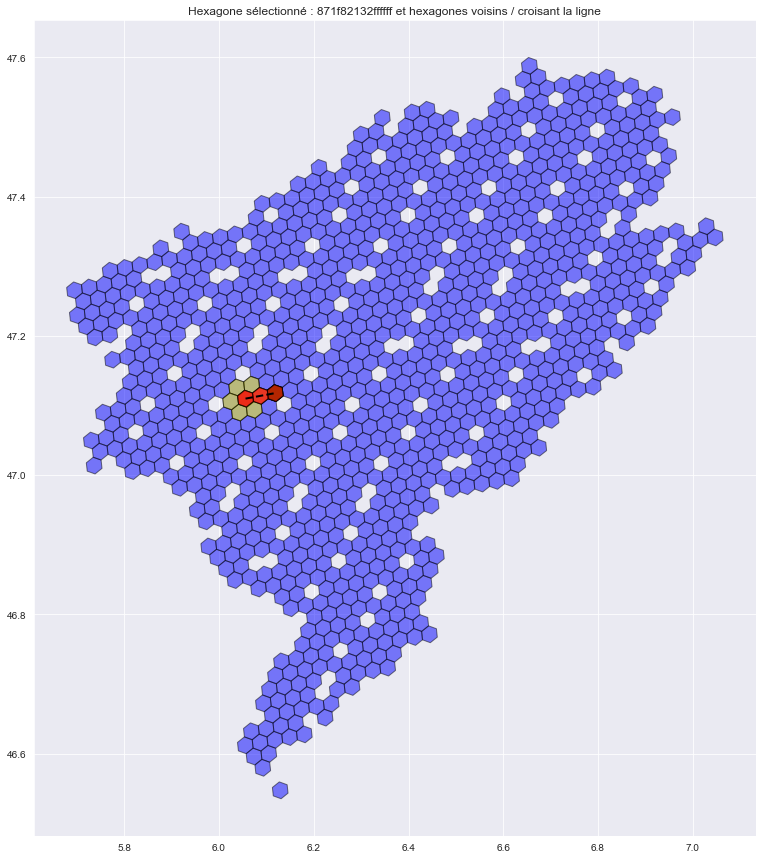

In [15]:
random_idx = random.choice(doubs_data.index)
hex_selection = doubs_data.loc[random_idx]

buffer_hex_selection = hex_selection.geometry.buffer(0.012)

hex_around_selection = firepoint_doubs[firepoint_doubs.geometry.intersects(buffer_hex_selection)]

id_caserne_proche = hex_selection['id_caserne_proche']
caserne_proche = caserne[caserne['id_pg'] == id_caserne_proche]

hex_id_caserne = caserne_proche['hex_id'].values[0]
hex_caserne = doubs_data[doubs_data['hex_id'] == hex_id_caserne]

centroid_hex_selection = hex_selection.geometry.centroid
centroid_hex_caserne = hex_caserne.geometry.centroid.values[0]

line = LineString([centroid_hex_selection, centroid_hex_caserne])

hex_intersecting_line = firepoint_doubs[firepoint_doubs.geometry.intersects(line)]

print("Hexagones voisins (buffer autour de l'hexagone sélectionné) :")
print(hex_around_selection[['hex_id', 'geometry']])

print("\nHexagones qui croisent la ligne tracée vers la caserne :")
print(hex_intersecting_line[['hex_id', 'geometry']])

fig, ax = plt.subplots(figsize=(15, 15))

firepoint_doubs.plot(ax=ax, color="blue", edgecolor="black", alpha=0.5)

gpd.GeoSeries(hex_selection.geometry).plot(ax=ax, color="purple", edgecolor="black", alpha=0.7)

hex_around_selection.plot(ax=ax, color="yellow", edgecolor="black", alpha=0.5)

gpd.GeoSeries(hex_caserne.geometry).plot(ax=ax, color="green", edgecolor="black", alpha=0.7)

gpd.GeoSeries(line).plot(ax=ax, color="black", linewidth=2, linestyle="dashed")

hex_intersecting_line.plot(ax=ax, color="red", edgecolor="black", alpha=0.7)

plt.title(f"Hexagone sélectionné : {hex_selection['hex_id']} et hexagones voisins / croisant la ligne")

plt.show()

In [16]:
hex_combined = pd.concat([hex_around_selection[['hex_id']], hex_intersecting_line[['hex_id']]])
hex_combined_unique = hex_combined.drop_duplicates().reset_index(drop=True)

print("\nTableau des hexagones uniques trouvés :")
print(hex_combined_unique)


Tableau des hexagones uniques trouvés :
            hex_id
0  871f82c49ffffff
1  871f82136ffffff
2  871f82130ffffff
3  871f82133ffffff
4  871f82c4dffffff
5  871f82114ffffff
6  871f82132ffffff
7  871f82106ffffff


In [17]:
def trouver_hex_interessants(row, firepoint_doubs, caserne, doubs_data):

    buffer_hex = row.geometry.buffer(0.012)

    hex_around = firepoint_doubs[firepoint_doubs.geometry.intersects(buffer_hex)]

    id_caserne_proche = row['id_caserne_proche']
    caserne_proche = caserne[caserne['id_pg'] == id_caserne_proche]

    if caserne_proche.empty:
        return []

    hex_id_caserne = caserne_proche['hex_id'].values[0]
    hex_caserne = doubs_data[doubs_data['hex_id'] == hex_id_caserne]

    if hex_caserne.empty:
        return []

    centroid_hex_selection = row.geometry.centroid
    centroid_hex_caserne = hex_caserne.geometry.centroid.values[0]

    line = LineString([centroid_hex_selection, centroid_hex_caserne])

    hex_intersecting_line = firepoint_doubs[firepoint_doubs.geometry.intersects(line)]

    hex_combined = pd.concat([hex_around[['hex_id']], hex_intersecting_line[['hex_id']]])
    hex_combined_unique = hex_combined.drop_duplicates().reset_index(drop=True)

    return hex_combined_unique['hex_id'].tolist()

doubs_data['hex_voisins'] = doubs_data.apply(lambda row: trouver_hex_interessants(row, firepoint_doubs, caserne, doubs_data), axis=1)

print(doubs_data[['hex_id', 'hex_voisins']].head())

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



            hex_id                                        hex_voisins
0  871f820aaffffff  [871f820a8ffffff, 871f820aaffffff, 871f82081ff...
1  871f82d61ffffff  [871f82d6cffffff, 871f82d61ffffff, 871f82992ff...
2  871f82d61ffffff  [871f82d6cffffff, 871f82d61ffffff, 871f82992ff...
3  871f82d4dffffff  [871f82d49ffffff, 871f82d4dffffff, 871f828b2ff...
4  871f82700ffffff  [871f82700ffffff, 871f82702ffffff, 871f82705ff...


In [18]:
def calculer_pourcentage_routes(row, firepoint_doubs):

    hex_voisins = row['hex_voisins']

    if not hex_voisins:
        return None

    hex_data = firepoint_doubs[firepoint_doubs['hex_id'].isin(hex_voisins)]

    if hex_data.empty:
        return None

    route_cols = ['motorway', 'primary', 'secondary', 'tertiary']
    return hex_data[route_cols].mean().mean()

doubs_data['pourcentage_routes'] = doubs_data.apply(lambda row: calculer_pourcentage_routes(row, firepoint_doubs), axis=1)

print(doubs_data[['hex_id', 'hex_voisins', 'pourcentage_routes']].head())

            hex_id                                        hex_voisins  \
0  871f820aaffffff  [871f820a8ffffff, 871f820aaffffff, 871f82081ff...   
1  871f82d61ffffff  [871f82d6cffffff, 871f82d61ffffff, 871f82992ff...   
2  871f82d61ffffff  [871f82d6cffffff, 871f82d61ffffff, 871f82992ff...   
3  871f82d4dffffff  [871f82d49ffffff, 871f82d4dffffff, 871f828b2ff...   
4  871f82700ffffff  [871f82700ffffff, 871f82702ffffff, 871f82705ff...   

   pourcentage_routes  
0            0.427856  
1            0.630443  
2            0.630443  
3            0.850521  
4            0.482042  


In [19]:
doubs_data.columns

Index(['hex_id', 'raison_sortie', 'date_debut', 'date_fin', 'label', 'year',
       'date', 'departement', 'duree_minutes', 'geometry', 'duree', 'centroid',
       'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday', 'scale0',
       'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway',
       'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'sinister', 'id_compagnie',
       'id_caserne_proche', 'distance_caserne_km', 'nb_casernes_10km',
       'hex_voisins', 'pourcentage_routes'],
      dtype='object')

In [20]:
doubs_clean = doubs_data.drop(columns=['hour', 'month', 'weekday', 'scale0', 'sinister', 'id_caserne_proche', 'hex_voisins', 'id_compagnie', 'departement', 'date', 'geometry', 'duree', 'centroid', 'raison_sortie', 'date_fin', 'date_debut', 'label', 'year'])

In [21]:
doubs_clean.columns

Index(['hex_id', 'duree_minutes', 'centroid_lon', 'centroid_lat', 'NDVI',
       'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway', 'primary',
       'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'distance_caserne_km', 'nb_casernes_10km',
       'pourcentage_routes'],
      dtype='object')

In [22]:
doubs_clean = doubs_clean.groupby('hex_id').mean().reset_index()

print(doubs_clean.head())

            hex_id  duree_minutes  centroid_lon  centroid_lat      NDVI  \
0  871f80492ffffff     117.325000      6.350198     47.477082  0.720443   
1  871f80493ffffff      79.483333      6.381746     47.480996  0.739361   
2  871f80498ffffff     160.133333      6.444873     47.488800  0.785204   
3  871f8049affffff      65.383333      6.431903     47.468880  0.778036   
4  871f8049cffffff      89.400000      6.426270     47.504821  0.751272   

       NDMI      NDBI      NDSI      NDWI  PasDeRoute  ...       tree  \
0  0.145452 -0.145452 -0.593620 -0.672639   96.116627  ...  35.314817   
1  0.162564 -0.162564 -0.599609 -0.688388   95.966830  ...  49.805252   
2  0.193932 -0.193932 -0.627573 -0.728378   97.701871  ...  86.613086   
3  0.189057 -0.189057 -0.623016 -0.721208   96.609318  ...  48.172799   
4  0.175163 -0.175163 -0.599002 -0.693667   96.231629  ...  40.723527   

       grass     crops     shrub   flooded     built  bare  snow  \
0  25.637803  0.062838  4.700264  0.000000

In [23]:
nan_check = doubs_clean.isna().sum()

print("Nombre de NaN dans chaque colonne :")
print(nan_check)

Nombre de NaN dans chaque colonne :
hex_id                    0
duree_minutes             0
centroid_lon              0
centroid_lat              0
NDVI                      0
NDMI                      0
NDBI                      0
NDSI                      0
NDWI                      0
PasDeRoute                0
motorway                  0
primary                   0
secondary                 0
tertiary                  0
path                      0
population                0
elevation                 0
foret_encoder             0
highway_encoder           0
PasDeforet                0
Châtaignier               0
Chênes décidus            0
Conifères                 0
Douglas                   0
Feuillus                  0
Hêtre                     0
Mixte                     0
Mélèze                    0
NC                        0
NR                        0
Peuplier                  0
Pin autre                 0
Pin laricio, pin noir     0
Pin maritime              0
Pin sylvestr

In [24]:
doubs_clean.shape

(627, 49)

In [25]:
doubs_clean = doubs_clean.dropna()

In [26]:
y = doubs_clean['duree_minutes']

X = doubs_clean.drop(columns=['hex_id', 'duree_minutes'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(objective="reg:squarederror", random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f" Performance du modèle XGBoost :")
print(f" MAE  : {mae:.4f}")
print(f" MSE  : {mse:.4f}")
print(f" RMSE : {rmse:.4f}")
print(f" R²   : {r2:.4f}")

 Performance du modèle XGBoost :
 MAE  : 57.7696
 MSE  : 17788.0870
 RMSE : 133.3720
 R²   : -2.7817


In [27]:
doubs_original = doubs_data.drop(columns=['hour', 'month', 'weekday', 'scale0', 'sinister', 'id_caserne_proche', 'hex_voisins', 'id_compagnie', 'departement', 'date', 'geometry', 'duree', 'centroid', 'raison_sortie', 'date_fin', 'date_debut', 'label', 'year', 'pourcentage_routes'])

In [28]:
doubs_original = doubs_original.groupby('hex_id').mean().reset_index()

print(doubs_clean.head())

            hex_id  duree_minutes  centroid_lon  centroid_lat      NDVI  \
0  871f80492ffffff     117.325000      6.350198     47.477082  0.720443   
1  871f80493ffffff      79.483333      6.381746     47.480996  0.739361   
2  871f80498ffffff     160.133333      6.444873     47.488800  0.785204   
3  871f8049affffff      65.383333      6.431903     47.468880  0.778036   
4  871f8049cffffff      89.400000      6.426270     47.504821  0.751272   

       NDMI      NDBI      NDSI      NDWI  PasDeRoute  ...       tree  \
0  0.145452 -0.145452 -0.593620 -0.672639   96.116627  ...  35.314817   
1  0.162564 -0.162564 -0.599609 -0.688388   95.966830  ...  49.805252   
2  0.193932 -0.193932 -0.627573 -0.728378   97.701871  ...  86.613086   
3  0.189057 -0.189057 -0.623016 -0.721208   96.609318  ...  48.172799   
4  0.175163 -0.175163 -0.599002 -0.693667   96.231629  ...  40.723527   

       grass     crops     shrub   flooded     built  bare  snow  \
0  25.637803  0.062838  4.700264  0.000000

In [29]:
y = doubs_original['duree_minutes']

X = doubs_original.drop(columns=['hex_id', 'duree_minutes'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(objective="reg:squarederror", random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f" Performance du modèle XGBoost :")
print(f" MAE  : {mae:.4f}")
print(f" MSE  : {mse:.4f}")
print(f" RMSE : {rmse:.4f}")
print(f" R²   : {r2:.4f}")

 Performance du modèle XGBoost :
 MAE  : 38.3583
 MSE  : 3013.2570
 RMSE : 54.8931
 R²   : -0.5344


In [30]:
y = doubs_original['duree_minutes']
X = doubs_original.drop(columns=['hex_id', 'duree_minutes'])

q1 = y.quantile(0.33)
q2 = y.quantile(0.66)

low_group = doubs_original[doubs_original['duree_minutes'] <= q1]
median_group = doubs_original[(doubs_original['duree_minutes'] > q1) & (doubs_original['duree_minutes'] <= q2)]
high_group = doubs_original[doubs_original['duree_minutes'] > q2]

def evaluate_model_on_group(group, X_full, y_full):
    X_group = group.drop(columns=['hex_id', 'duree_minutes'])
    y_group = group['duree_minutes']

    X_train, X_test, y_train, y_test = train_test_split(X_group, y_group, test_size=0.2, random_state=42)

    model = XGBRegressor(objective="reg:squarederror", random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    mean_duree = group['duree_minutes'].mean()
    max_duree = group['duree_minutes'].max()
    min_duree = group['duree_minutes'].min()

    return mae, mse, rmse, r2, mean_duree, max_duree, min_duree

low_mae, low_mse, low_rmse, low_r2, low_mean, low_max, low_min = evaluate_model_on_group(low_group, X, y)
median_mae, median_mse, median_rmse, median_r2, median_mean, median_max, median_min = evaluate_model_on_group(median_group, X, y)
high_mae, high_mse, high_rmse, high_r2, high_mean, high_max, high_min = evaluate_model_on_group(high_group, X, y)

print(f" Performance du modèle XGBoost :")
print(f" Groupe 1 - 33% les plus faibles :")
print(f"    MAE      : {low_mae:.4f}")
print(f"    MSE      : {low_mse:.4f}")
print(f"    RMSE     : {low_rmse:.4f}")
print(f"    R²       : {low_r2:.4f}")
print(f"    Moyenne  : {low_mean:.4f}")
print(f"    Max      : {low_max:.4f}")
print(f"    Min      : {low_min:.4f}")
print("\n")

print(f" Groupe 2 - Médianes :")
print(f"    MAE      : {median_mae:.4f}")
print(f"    MSE      : {median_mse:.4f}")
print(f"    RMSE     : {median_rmse:.4f}")
print(f"    R²       : {median_r2:.4f}")
print(f"    Moyenne  : {median_mean:.4f}")
print(f"    Max      : {median_max:.4f}")
print(f"    Min      : {median_min:.4f}")
print("\n")

print(f" Groupe 3 - 33% les plus élevées :")
print(f"    MAE      : {high_mae:.4f}")
print(f"    MSE      : {high_mse:.4f}")
print(f"    RMSE     : {high_rmse:.4f}")
print(f"    R²       : {high_r2:.4f}")
print(f"    Moyenne  : {high_mean:.4f}")
print(f"    Max      : {high_max:.4f}")
print(f"    Min      : {high_min:.4f}")

 Performance du modèle XGBoost :
 Groupe 1 - 33% les plus faibles :
    MAE      : 9.3451
    MSE      : 119.8664
    RMSE     : 10.9483
    R²       : -0.2015
    Moyenne  : 55.9409
    Max      : 70.8167
    Min      : 2.8500


 Groupe 2 - Médianes :
    MAE      : 8.4173
    MSE      : 101.4310
    RMSE     : 10.0713
    R²       : -0.4731
    Moyenne  : 85.1236
    Max      : 99.9083
    Min      : 70.9542


 Groupe 3 - 33% les plus élevées :
    MAE      : 66.3266
    MSE      : 10999.9401
    RMSE     : 104.8806
    R²       : -1.5125
    Moyenne  : 168.7851
    Max      : 1401.5333
    Min      : 100.0583


In [31]:
y = doubs_original['duree_minutes']
X = doubs_original.drop(columns=['hex_id', 'duree_minutes'])

q1 = y.quantile(0.2)
q2 = y.quantile(0.4)
q3 = y.quantile(0.6)
q4 = y.quantile(0.8)

low_group = doubs_original[doubs_original['duree_minutes'] <= q1]
low_middle_group = doubs_original[(doubs_original['duree_minutes'] > q1) & (doubs_original['duree_minutes'] <= q2)]
middle_group = doubs_original[(doubs_original['duree_minutes'] > q2) & (doubs_original['duree_minutes'] <= q3)]
high_middle_group = doubs_original[(doubs_original['duree_minutes'] > q3) & (doubs_original['duree_minutes'] <= q4)]
high_group = doubs_original[doubs_original['duree_minutes'] > q4]

def evaluate_model_on_group(group, X_full, y_full):
    X_group = group.drop(columns=['hex_id', 'duree_minutes'])
    y_group = group['duree_minutes']

    X_train, X_test, y_train, y_test = train_test_split(X_group, y_group, test_size=0.2, random_state=42)

    model = XGBRegressor(objective="reg:squarederror", random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    mean_duree = group['duree_minutes'].mean()
    max_duree = group['duree_minutes'].max()
    min_duree = group['duree_minutes'].min()

    return mae, mse, rmse, r2, mean_duree, max_duree, min_duree

low_mae, low_mse, low_rmse, low_r2, low_mean, low_max, low_min = evaluate_model_on_group(low_group, X, y)
low_middle_mae, low_middle_mse, low_middle_rmse, low_middle_r2, low_middle_mean, low_middle_max, low_middle_min = evaluate_model_on_group(low_middle_group, X, y)
middle_mae, middle_mse, middle_rmse, middle_r2, middle_mean, middle_max, middle_min = evaluate_model_on_group(middle_group, X, y)
high_middle_mae, high_middle_mse, high_middle_rmse, high_middle_r2, high_middle_mean, high_middle_max, high_middle_min = evaluate_model_on_group(high_middle_group, X, y)
high_mae, high_mse, high_rmse, high_r2, high_mean, high_max, high_min = evaluate_model_on_group(high_group, X, y)

print(f" Performance du modèle XGBoost :")
print(f" Groupe 1 - 20% les plus faibles :")
print(f"    MAE      : {low_mae:.4f}")
print(f"    MSE      : {low_mse:.4f}")
print(f"    RMSE     : {low_rmse:.4f}")
print(f"    R²       : {low_r2:.4f}")
print(f"    Moyenne  : {low_mean:.4f}")
print(f"    Max      : {low_max:.4f}")
print(f"    Min      : {low_min:.4f}")
print("\n")

print(f" Groupe 2 - 20% faibles :")
print(f"    MAE      : {low_middle_mae:.4f}")
print(f"    MSE      : {low_middle_mse:.4f}")
print(f"    RMSE     : {low_middle_rmse:.4f}")
print(f"    R²       : {low_middle_r2:.4f}")
print(f"    Moyenne  : {low_middle_mean:.4f}")
print(f"    Max      : {low_middle_max:.4f}")
print(f"    Min      : {low_middle_min:.4f}")
print("\n")

print(f" Groupe 3 - Moyenne :")
print(f"    MAE      : {middle_mae:.4f}")
print(f"    MSE      : {middle_mse:.4f}")
print(f"    RMSE     : {middle_rmse:.4f}")
print(f"    R²       : {middle_r2:.4f}")
print(f"    Moyenne  : {middle_mean:.4f}")
print(f"    Max      : {middle_max:.4f}")
print(f"    Min      : {middle_min:.4f}")
print("\n")

print(f" Groupe 4 - 20% haut :")
print(f"    MAE      : {high_middle_mae:.4f}")
print(f"    MSE      : {high_middle_mse:.4f}")
print(f"    RMSE     : {high_middle_rmse:.4f}")
print(f"    R²       : {high_middle_r2:.4f}")
print(f"    Moyenne  : {high_middle_mean:.4f}")
print(f"    Max      : {high_middle_max:.4f}")
print(f"    Min      : {high_middle_min:.4f}")
print("\n")

print(f" Groupe 5 - 20% les plus élevés :")
print(f"    MAE      : {high_mae:.4f}")
print(f"    MSE      : {high_mse:.4f}")
print(f"    RMSE     : {high_rmse:.4f}")
print(f"    R²       : {high_r2:.4f}")
print(f"    Moyenne  : {high_mean:.4f}")
print(f"    Max      : {high_max:.4f}")
print(f"    Min      : {high_min:.4f}")


 Performance du modèle XGBoost :
 Groupe 1 - 20% les plus faibles :
    MAE      : 8.6440
    MSE      : 116.8953
    RMSE     : 10.8118
    R²       : -0.3430
    Moyenne  : 49.2124
    Max      : 61.5167
    Min      : 2.8500


 Groupe 2 - 20% faibles :
    MAE      : 4.3860
    MSE      : 28.2064
    RMSE     : 5.3110
    R²       : -0.6679
    Moyenne  : 69.0410
    Max      : 76.4250
    Min      : 61.5278


 Groupe 3 - Moyenne :
    MAE      : 6.4187
    MSE      : 55.8147
    RMSE     : 7.4709
    R²       : -0.3067
    Moyenne  : 85.2034
    Max      : 95.0806
    Min      : 76.4333


 Groupe 4 - 20% haut :
    MAE      : 8.3993
    MSE      : 95.0074
    RMSE     : 9.7472
    R²       : -0.1027
    Moyenne  : 107.5525
    Max      : 126.1500
    Min      : 95.2944


 Groupe 5 - 20% les plus élevés :
    MAE      : 115.2539
    MSE      : 69734.2576
    RMSE     : 264.0724
    R²       : -0.2079
    Moyenne  : 208.1443
    Max      : 1401.5333
    Min      : 126.1583


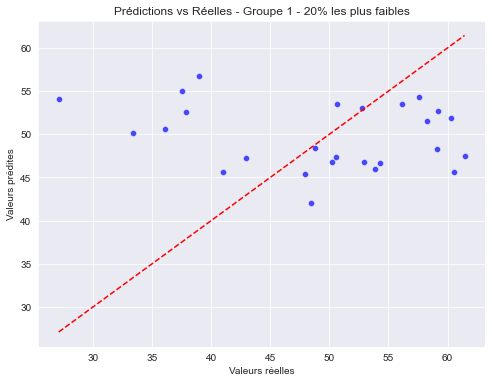

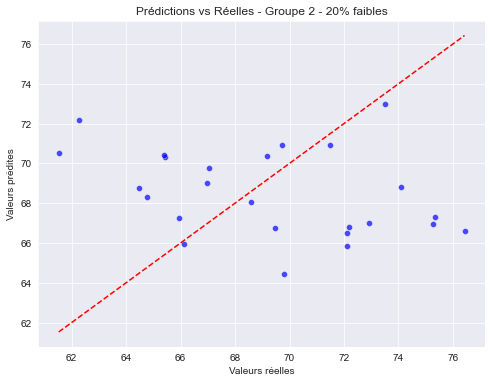

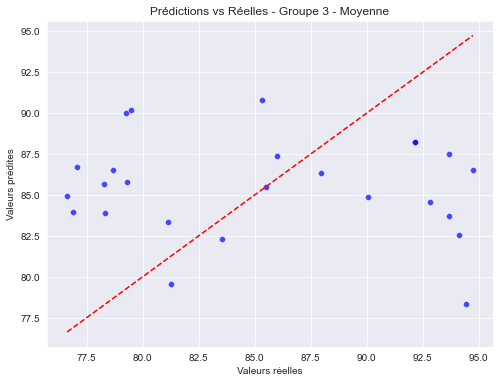

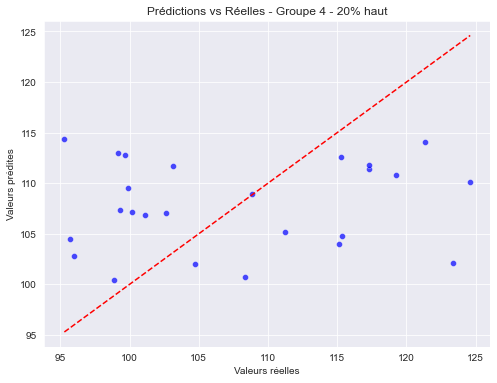

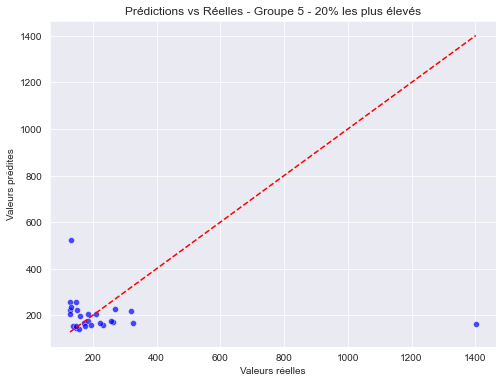

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_predictions_vs_true(y_test, y_pred, group_name):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.7)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
    plt.title(f"Prédictions vs Réelles - {group_name}")
    plt.xlabel('Valeurs réelles')
    plt.ylabel('Valeurs prédites')
    plt.show()

def plot_for_all_groups():
    def plot_group(group, group_name):
        X_group = group.drop(columns=['hex_id', 'duree_minutes'])
        y_group = group['duree_minutes']
        X_train, X_test, y_train, y_test = train_test_split(X_group, y_group, test_size=0.2, random_state=42)

        model = XGBRegressor(objective="reg:squarederror", random_state=42)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        plot_predictions_vs_true(y_test, y_pred, group_name)

    plot_group(low_group, 'Groupe 1 - 20% les plus faibles')
    plot_group(low_middle_group, 'Groupe 2 - 20% faibles')
    plot_group(middle_group, 'Groupe 3 - Moyenne')
    plot_group(high_middle_group, 'Groupe 4 - 20% haut')
    plot_group(high_group, 'Groupe 5 - 20% les plus élevés')

plot_for_all_groups()

In [33]:
y = doubs_original['duree_minutes']
X = doubs_original.drop(columns=['hex_id', 'duree_minutes'])

q1 = y.quantile(0.33)
q2 = y.quantile(0.66)

low_group = doubs_original[doubs_original['duree_minutes'] <= q1]
median_group = doubs_original[(doubs_original['duree_minutes'] > q1) & (doubs_original['duree_minutes'] <= q2)]
high_group = doubs_original[doubs_original['duree_minutes'] > q2]

def evaluate_model_on_group(group, X_train_full, y_train_full, X_test_group, y_test_group):
    model = XGBRegressor(objective="reg:squarederror", random_state=42)
    model.fit(X_train_full, y_train_full)

    y_pred = model.predict(X_test_group)

    mae = mean_absolute_error(y_test_group, y_pred)
    mse = mean_squared_error(y_test_group, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_group, y_pred)

    mean_duree = group['duree_minutes'].mean()
    max_duree = group['duree_minutes'].max()
    min_duree = group['duree_minutes'].min()

    return mae, mse, rmse, r2, mean_duree, max_duree, min_duree

low_X = X.loc[low_group.index]
median_X = X.loc[median_group.index]
high_X = X.loc[high_group.index]

low_X_train, low_X_test, low_y_train, low_y_test = train_test_split(low_X, low_group['duree_minutes'], test_size=0.33, random_state=42)
median_X_train, median_X_test, median_y_train, median_y_test = train_test_split(median_X, median_group['duree_minutes'], test_size=0.33, random_state=42)
high_X_train, high_X_test, high_y_train, high_y_test = train_test_split(high_X, high_group['duree_minutes'], test_size=0.33, random_state=42)

low_mae, low_mse, low_rmse, low_r2, low_mean, low_max, low_min = evaluate_model_on_group(low_group,
                                                                                          low_X_train, low_y_train,
                                                                                          low_X_test, low_y_test)

median_mae, median_mse, median_rmse, median_r2, median_mean, median_max, median_min = evaluate_model_on_group(median_group,
                                                                                                           median_X_train, median_y_train,
                                                                                                           median_X_test, median_y_test)

high_mae, high_mse, high_rmse, high_r2, high_mean, high_max, high_min = evaluate_model_on_group(high_group,
                                                                                             high_X_train, high_y_train,
                                                                                             high_X_test, high_y_test)

print(f" Performance du modèle XGBoost :")
print(f" Groupe 1 - 33% les plus faibles :")
print(f"    MAE      : {low_mae:.4f}")
print(f"    MSE      : {low_mse:.4f}")
print(f"    RMSE     : {low_rmse:.4f}")
print(f"    R²       : {low_r2:.4f}")
print(f"    Moyenne  : {low_mean:.4f}")
print(f"    Max      : {low_max:.4f}")
print(f"    Min      : {low_min:.4f}")
print("\n")

print(f" Groupe 2 - Médianes :")
print(f"    MAE      : {median_mae:.4f}")
print(f"    MSE      : {median_mse:.4f}")
print(f"    RMSE     : {median_rmse:.4f}")
print(f"    R²       : {median_r2:.4f}")
print(f"    Moyenne  : {median_mean:.4f}")
print(f"    Max      : {median_max:.4f}")
print(f"    Min      : {median_min:.4f}")
print("\n")

print(f" Groupe 3 - 33% les plus élevées :")
print(f"    MAE      : {high_mae:.4f}")
print(f"    MSE      : {high_mse:.4f}")
print(f"    RMSE     : {high_rmse:.4f}")
print(f"    R²       : {high_r2:.4f}")
print(f"    Moyenne  : {high_mean:.4f}")
print(f"    Max      : {high_max:.4f}")
print(f"    Min      : {high_min:.4f}")

 Performance du modèle XGBoost :
 Groupe 1 - 33% les plus faibles :
    MAE      : 8.7505
    MSE      : 114.0362
    RMSE     : 10.6788
    R²       : -0.0445
    Moyenne  : 55.9409
    Max      : 70.8167
    Min      : 2.8500


 Groupe 2 - Médianes :
    MAE      : 8.1082
    MSE      : 94.8557
    RMSE     : 9.7394
    R²       : -0.3046
    Moyenne  : 85.1236
    Max      : 99.9083
    Min      : 70.9542


 Groupe 3 - 33% les plus élevées :
    MAE      : 80.8589
    MSE      : 35872.2249
    RMSE     : 189.3996
    R²       : -0.2059
    Moyenne  : 168.7851
    Max      : 1401.5333
    Min      : 100.0583


In [34]:
y = doubs_original['duree_minutes']
X = doubs_original.drop(columns=['hex_id', 'duree_minutes'])

q1 = y.quantile(0.2)
q2 = y.quantile(0.4)
q3 = y.quantile(0.6)
q4 = y.quantile(0.8)

group1 = doubs_original[doubs_original['duree_minutes'] <= q1]
group2 = doubs_original[(doubs_original['duree_minutes'] > q1) & (doubs_original['duree_minutes'] <= q2)]
group3 = doubs_original[(doubs_original['duree_minutes'] > q2) & (doubs_original['duree_minutes'] <= q3)]
group4 = doubs_original[(doubs_original['duree_minutes'] > q3) & (doubs_original['duree_minutes'] <= q4)]
group5 = doubs_original[doubs_original['duree_minutes'] > q4]

def evaluate_model_on_group(group, X_train_full, y_train_full, X_test_group, y_test_group):
    model = XGBRegressor(objective="reg:squarederror", random_state=42)
    model.fit(X_train_full, y_train_full)

    y_pred = model.predict(X_test_group)

    mae = mean_absolute_error(y_test_group, y_pred)
    mse = mean_squared_error(y_test_group, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_group, y_pred)

    mean_duree = group['duree_minutes'].mean()
    max_duree = group['duree_minutes'].max()
    min_duree = group['duree_minutes'].min()

    return mae, mse, rmse, r2, mean_duree, max_duree, min_duree

group1_X = X.loc[group1.index]
group2_X = X.loc[group2.index]
group3_X = X.loc[group3.index]
group4_X = X.loc[group4.index]
group5_X = X.loc[group5.index]

group1_X_train, group1_X_test, group1_y_train, group1_y_test = train_test_split(group1_X, group1['duree_minutes'], test_size=0.33, random_state=42)
group2_X_train, group2_X_test, group2_y_train, group2_y_test = train_test_split(group2_X, group2['duree_minutes'], test_size=0.33, random_state=42)
group3_X_train, group3_X_test, group3_y_train, group3_y_test = train_test_split(group3_X, group3['duree_minutes'], test_size=0.33, random_state=42)
group4_X_train, group4_X_test, group4_y_train, group4_y_test = train_test_split(group4_X, group4['duree_minutes'], test_size=0.33, random_state=42)
group5_X_train, group5_X_test, group5_y_train, group5_y_test = train_test_split(group5_X, group5['duree_minutes'], test_size=0.33, random_state=42)

group1_mae, group1_mse, group1_rmse, group1_r2, group1_mean, group1_max, group1_min = evaluate_model_on_group(group1,
                                                                                                              group1_X_train, group1_y_train,
                                                                                                              group1_X_test, group1_y_test)

group2_mae, group2_mse, group2_rmse, group2_r2, group2_mean, group2_max, group2_min = evaluate_model_on_group(group2,
                                                                                                              group2_X_train, group2_y_train,
                                                                                                              group2_X_test, group2_y_test)

group3_mae, group3_mse, group3_rmse, group3_r2, group3_mean, group3_max, group3_min = evaluate_model_on_group(group3,
                                                                                                              group3_X_train, group3_y_train,
                                                                                                              group3_X_test, group3_y_test)

group4_mae, group4_mse, group4_rmse, group4_r2, group4_mean, group4_max, group4_min = evaluate_model_on_group(group4,
                                                                                                              group4_X_train, group4_y_train,
                                                                                                              group4_X_test, group4_y_test)

group5_mae, group5_mse, group5_rmse, group5_r2, group5_mean, group5_max, group5_min = evaluate_model_on_group(group5,
                                                                                                              group5_X_train, group5_y_train,
                                                                                                              group5_X_test, group5_y_test)

print(f" Performance du modèle XGBoost :")
print(f" Groupe 1 - 20% les plus faibles :")
print(f"    MAE      : {group1_mae:.4f}")
print(f"    MSE      : {group1_mse:.4f}")
print(f"    RMSE     : {group1_rmse:.4f}")
print(f"    R²       : {group1_r2:.4f}")
print(f"    Moyenne  : {group1_mean:.4f}")
print(f"    Max      : {group1_max:.4f}")
print(f"    Min      : {group1_min:.4f}")
print("\n")

print(f" Groupe 2 - Entre 20% et 40% :")
print(f"    MAE      : {group2_mae:.4f}")
print(f"    MSE      : {group2_mse:.4f}")
print(f"    RMSE     : {group2_rmse:.4f}")
print(f"    R²       : {group2_r2:.4f}")
print(f"    Moyenne  : {group2_mean:.4f}")
print(f"    Max      : {group2_max:.4f}")
print(f"    Min      : {group2_min:.4f}")
print("\n")

print(f" Groupe 3 - Entre 40% et 60% :")
print(f"    MAE      : {group3_mae:.4f}")
print(f"    MSE      : {group3_mse:.4f}")
print(f"    RMSE     : {group3_rmse:.4f}")
print(f"    R²       : {group3_r2:.4f}")
print(f"    Moyenne  : {group3_mean:.4f}")
print(f"    Max      : {group3_max:.4f}")
print(f"    Min      : {group3_min:.4f}")
print("\n")

print(f" Groupe 4 - Entre 60% et 80% :")
print(f"    MAE      : {group4_mae:.4f}")
print(f"    MSE      : {group4_mse:.4f}")
print(f"    RMSE     : {group4_rmse:.4f}")
print(f"    R²       : {group4_r2:.4f}")
print(f"    Moyenne  : {group4_mean:.4f}")
print(f"    Max      : {group4_max:.4f}")
print(f"    Min      : {group4_min:.4f}")
print("\n")

print(f" Groupe 5 - 20% les plus élevés :")
print(f"    MAE      : {group5_mae:.4f}")
print(f"    MSE      : {group5_mse:.4f}")
print(f"    RMSE     : {group5_rmse:.4f}")
print(f"    R²       : {group5_r2:.4f}")
print(f"    Moyenne  : {group5_mean:.4f}")
print(f"    Max      : {group5_max:.4f}")
print(f"    Min      : {group5_min:.4f}")

 Performance du modèle XGBoost :
 Groupe 1 - 20% les plus faibles :
    MAE      : 8.7251
    MSE      : 130.9579
    RMSE     : 11.4437
    R²       : -0.4199
    Moyenne  : 49.2124
    Max      : 61.5167
    Min      : 2.8500


 Groupe 2 - Entre 20% et 40% :
    MAE      : 3.7144
    MSE      : 21.8159
    RMSE     : 4.6708
    R²       : -0.3440
    Moyenne  : 69.0410
    Max      : 76.4250
    Min      : 61.5278


 Groupe 3 - Entre 40% et 60% :
    MAE      : 5.8106
    MSE      : 48.6283
    RMSE     : 6.9734
    R²       : -0.3448
    Moyenne  : 85.2034
    Max      : 95.0806
    Min      : 76.4333


 Groupe 4 - Entre 60% et 80% :
    MAE      : 8.7236
    MSE      : 116.0966
    RMSE     : 10.7748
    R²       : -0.3434
    Moyenne  : 107.5525
    Max      : 126.1500
    Min      : 95.2944


 Groupe 5 - 20% les plus élevés :
    MAE      : 88.4018
    MSE      : 43415.6899
    RMSE     : 208.3643
    R²       : -0.0246
    Moyenne  : 208.1443
    Max      : 1401.5333
    Min    

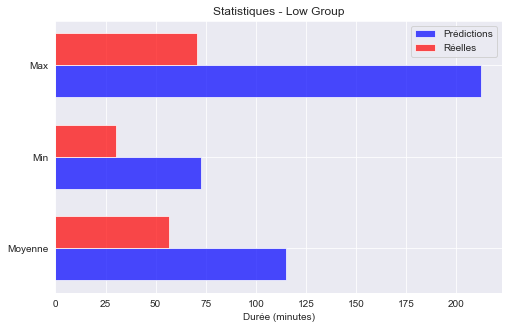

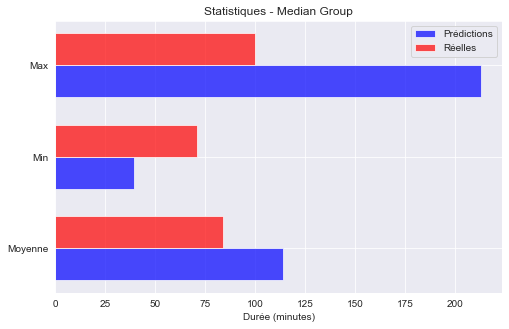

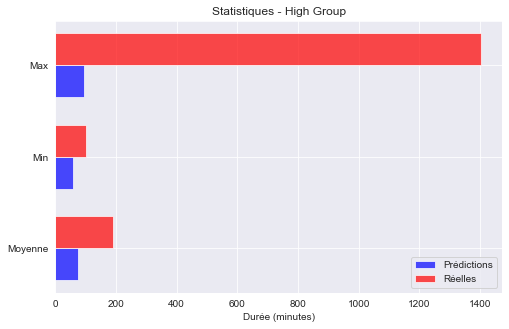

In [35]:
def plot_stats_bar_chart(y_pred, y_true, group_name):
    stats_pred = [np.mean(y_pred), np.min(y_pred), np.max(y_pred)]
    stats_true = [np.mean(y_true), np.min(y_true), np.max(y_true)]

    labels = ['Moyenne', 'Min', 'Max']
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(x - width/2, stats_pred, width, label='Prédictions', color='blue', alpha=0.7)
    ax.barh(x + width/2, stats_true, width, label='Réelles', color='red', alpha=0.7)

    ax.set_xlabel('Durée (minutes)')
    ax.set_title(f'Statistiques - {group_name}')
    ax.set_yticks(x)
    ax.set_yticklabels(labels)
    ax.legend()

    plt.show()

def train_and_evaluate(train_X, train_y, test_X, test_y, group_name):
    model = XGBRegressor(objective="reg:squarederror", random_state=42)
    model.fit(train_X, train_y)

    y_pred = model.predict(test_X)

    plot_stats_bar_chart(y_pred, test_y, group_name)

y = doubs_original['duree_minutes']
X = doubs_original.drop(columns=['hex_id', 'duree_minutes'])

q1 = y.quantile(0.33)
q2 = y.quantile(0.66)

low_group = doubs_original[doubs_original['duree_minutes'] <= q1]
median_group = doubs_original[(doubs_original['duree_minutes'] > q1) & (doubs_original['duree_minutes'] <= q2)]
high_group = doubs_original[doubs_original['duree_minutes'] > q2]

low_X = X.loc[low_group.index]
median_X = X.loc[median_group.index]
high_X = X.loc[high_group.index]

low_y = y.loc[low_group.index]
median_y = y.loc[median_group.index]
high_y = y.loc[high_group.index]

train_X_low = X.drop(low_group.index)
train_y_low = y.drop(low_group.index)

train_X_median = X.drop(median_group.index)
train_y_median = y.drop(median_group.index)

train_X_high = X.drop(high_group.index)
train_y_high = y.drop(high_group.index)

low_X_train, low_X_test, low_y_train, low_y_test = train_test_split(low_X, low_y, test_size=0.33, random_state=42)
median_X_train, median_X_test, median_y_train, median_y_test = train_test_split(median_X, median_y, test_size=0.33, random_state=42)
high_X_train, high_X_test, high_y_train, high_y_test = train_test_split(high_X, high_y, test_size=0.33, random_state=42)

train_and_evaluate(train_X_low, train_y_low, low_X_test, low_y_test, "Low Group")
train_and_evaluate(train_X_median, train_y_median, median_X_test, median_y_test, "Median Group")
train_and_evaluate(train_X_high, train_y_high, high_X_test, high_y_test, "High Group")